# 05 - Ensemble Learning

**Estimated time:** 90-120 minutes  
**Prerequisites:** notebooks 00-04; bagging, boosting, and CV.  
**Level:** practical intermediate machine learning  
**Dataset:** Bank Marketing subscription prediction  
**Main question:** when is an ensemble better than a strong single model?

## Why this notebook matters

Ensemble methods are popular because they often improve predictive performance. In real projects, however, a more complex model is not automatically a better model. A stacked ensemble can be slower, harder to explain, harder to monitor, and harder to debug than one strong gradient boosting model.

This notebook teaches a practical decision workflow:

1. Build strong single-model baselines.
2. Try the simplest ensemble first: soft voting.
3. Try stacking only after the baselines are clear.
4. Compare performance, speed, and operational complexity.
5. Make a recommendation that a real team could deploy.

## Learning objectives

By the end of this notebook, students should be able to:

- Explain the difference between bagging, boosting, voting, and stacking.
- Build leakage-safe preprocessing pipelines for multiple model families.
- Compare models with probability-based and threshold-based metrics.
- Interpret when an ensemble improvement is meaningful and when it is noise.
- Recommend a production model using both metrics and practical constraints.


## Concept map

| Method | Simple explanation | Main strength | Main risk |
|---|---|---|---|
| Logistic regression | Linear baseline with calibrated-ish probabilities | Fast, simple, explainable | May underfit nonlinear patterns |
| Random forest | Many independent trees averaged together | Robust, handles nonlinearities | Can be slower and less well-calibrated |
| Gradient boosting | Trees built sequentially to fix previous mistakes | Usually strong on tabular data | Can overfit if poorly regularized |
| Soft voting | Average probabilities from several models | Simple ensemble | Weak or miscalibrated members can hurt |
| Stacking | Train a meta-model on base-model predictions | Can learn which model to trust | More complex and easier to misuse |

**Teaching note:** emphasize that ensemble learning is not a magic trick. It works best when base models are individually useful and make different kinds of errors.


In [12]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, log_loss, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 4)

SEED = 42
TARGET = "y"


## 1. Load the data

The target is whether a customer subscribed to a term deposit.

We remove `duration` because it is known only after a call ends. If the business goal is to decide whom to call before the call happens, `duration` is not available at prediction time. Keeping it would create **target leakage**.

**Class discussion:** ask students what information is available before a marketing call and what information is available only after the call.


In [13]:
def find_project_root():
    current = Path.cwd()
    if (current / "data" / "raw" / "bank-full.csv").exists():
        return current
    if (current.parent / "data" / "raw" / "bank-full.csv").exists():
        return current.parent
    raise FileNotFoundError("Could not find data/raw/bank-full.csv")

root = find_project_root()
data_path = root / "data" / "raw" / "bank-full.csv"

bank = pd.read_csv(data_path, sep=";")
bank[TARGET] = bank[TARGET].map({"no": 0, "yes": 1})
bank = bank.drop(columns=["duration"])

print(f"Rows: {bank.shape[0]:,}")
print(f"Features after removing leakage: {bank.shape[1] - 1}")
display(bank.head())


Rows: 45,211
Features after removing leakage: 15


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,0


In [14]:
class_balance = (
    bank[TARGET]
    .value_counts(normalize=True)
    .rename(index={0: "no", 1: "yes"})
    .mul(100)
    .round(2)
)

class_balance.to_frame("percentage")


,percentage
y,
no,88.3
yes,11.7


### Interpretation

The positive class is much smaller than the negative class. Accuracy would be misleading here because a model can predict "no" for almost everyone and still look accurate.

For this notebook, we use:

- **Log loss:** rewards good probability estimates and punishes confident wrong predictions.
- **ROC AUC:** checks ranking quality across thresholds.
- **Precision:** of the customers predicted as positive, how many actually subscribe?
- **Recall:** of the real subscribers, how many did we find?
- **Prediction speed:** a simple operational signal.


## 2. Create a development and validation split

We use a single validation set for teaching clarity. In high-stakes projects, use cross-validation or a separate final test set before making a production decision.

The split is stratified so the subscription rate stays similar in both sets.


In [15]:
X = bank.drop(columns=TARGET)
y = bank[TARGET]

X_dev, X_val, y_dev, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "rows": [len(X_dev), len(X_val)],
    "positive_rate": [y_dev.mean(), y_val.mean()],
}, index=["development", "validation"])

split_summary


,rows,positive_rate
development,33908,0.117
validation,11303,0.117


## 3. Build one clear preprocessing pipeline

The same preprocessing is used for every model so the model comparison stays fair.

- Numeric columns: fill missing values with the median.
- Categorical columns: fill missing values with the most frequent value, then one-hot encode.
- Logistic regression also scales numeric columns because linear models are sensitive to feature scale.
- Tree models do not need numeric scaling.

**Best practice:** preprocessing must be inside the pipeline so it is fitted only on training data during model fitting.


In [16]:
numeric_features = X_dev.select_dtypes(include="number").columns.tolist()
categorical_features = X_dev.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [17]:
numeric_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

scaled_numeric_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_preprocess, numeric_features),
    ("cat", categorical_preprocess, categorical_features),
])

scaled_preprocess = ColumnTransformer([
    ("num", scaled_numeric_preprocess, numeric_features),
    ("cat", categorical_preprocess, categorical_features),
])


## 4. Train practical baseline models

A common mistake is to build an ensemble before knowing whether one strong model is already enough.

We use three complementary baselines:

- **Logistic regression:** simple linear reference model.
- **Random forest:** bagging-based tree ensemble.
- **Gradient boosting:** boosting-based tree ensemble.

These models are intentionally not over-tuned. The goal is to teach a reliable comparison pattern, not to win a leaderboard.


In [18]:
def make_pipeline(model, scale_numeric=False):
    transformer = scaled_preprocess if scale_numeric else preprocess
    return Pipeline([
        ("preprocess", transformer),
        ("model", model),
    ])

models = {
    "logistic_regression": make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
        scale_numeric=True,
    ),
    "random_forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        )
    ),
    "gradient_boosting": make_pipeline(
        HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.04,
            max_leaf_nodes=31,
            min_samples_leaf=40,
            l2_regularization=0.1,
            random_state=SEED,
        )
    ),
}


In [19]:
def evaluate_model(name, model, X_train, y_train, X_valid, y_valid, threshold=0.5):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    probability = model.predict_proba(X_valid)[:, 1]
    predict_seconds = time.perf_counter() - start

    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, prediction, labels=[0, 1]).ravel()

    return {
        "model": name,
        "log_loss": log_loss(y_valid, probability),
        "roc_auc": roc_auc_score(y_valid, probability),
        "precision": precision_score(y_valid, prediction, zero_division=0),
        "recall": recall_score(y_valid, prediction, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "fit_seconds": fit_seconds,
        "prediction_ms_per_1000_rows": predict_seconds * 1000 / len(X_valid) * 1000,
    }

fitted_models = {}
results = []

for name, model in models.items():
    results.append(evaluate_model(name, model, X_dev, y_dev, X_val, y_val))
    fitted_models[name] = model

baseline_results = pd.DataFrame(results).set_index("model").sort_values("log_loss")
baseline_results.round(4)


,log_loss,roc_auc,precision,recall,false_positives,false_negatives,fit_seconds,prediction_ms_per_1000_rows
model,,,,,,,,
gradient_boosting,0.2814,0.8049,0.6393,0.2239,167,1026,0.7043,2.2077
random_forest,0.3893,0.8031,0.4474,0.5280,862,624,1.1339,5.4482
logistic_regression,0.5565,0.7733,0.2663,0.6392,2328,477,0.1619,1.6507


### Baseline reading guide

When reading the table, do not only ask "which number is best?" Ask:

- Does the model produce useful probabilities? Check log loss.
- Does it rank likely subscribers well? Check ROC AUC.
- Does it find enough subscribers? Check recall.
- Is the model practical to train and serve? Check timing columns.

**Teaching prompt:** if gradient boosting and stacking are nearly tied later, which one would you deploy and why?


## 5. Soft voting

Soft voting averages predicted probabilities from multiple models.

This is the easiest ensemble to explain:

> Each model votes with a probability, and we average those probabilities.

Soft voting can help when models make different errors. It can hurt when one model is much weaker or when probability scales are not comparable.


In [20]:
soft_vote = VotingClassifier(
    estimators=[
        ("lr", models["logistic_regression"]),
        ("rf", models["random_forest"]),
        ("gb", models["gradient_boosting"]),
    ],
    voting="soft",
    n_jobs=-1,
)

vote_result = evaluate_model("soft_vote", soft_vote, X_dev, y_dev, X_val, y_val)
fitted_models["soft_vote"] = soft_vote

pd.DataFrame([vote_result]).set_index("model").round(4)


,log_loss,roc_auc,precision,recall,false_positives,false_negatives,fit_seconds,prediction_ms_per_1000_rows
model,,,,,,,,
soft_vote,0.3722,0.8019,0.5093,0.4539,578,722,2.5274,26.165


### Voting discussion

Soft voting is attractive because it is simple. But simple does not always mean better.

If the voting ensemble is worse than the best single model, that is a useful result. It means the average probability is being pulled away from the strongest model.

**Practical lesson:** an ensemble should be compared against strong individual members, not only against weak baselines.


## 6. Stacking

Stacking trains a second-level model, called a meta-model, on predictions from the base models.

The important safety rule is:

> The meta-model must learn from out-of-fold predictions, not from predictions made by base models on the same rows they were trained on.

`StackingClassifier` handles this internally with cross-validation. That keeps the example simple and avoids leakage.


In [21]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

stack = StackingClassifier(
    estimators=[
        ("lr", models["logistic_regression"]),
        ("rf", models["random_forest"]),
        ("gb", models["gradient_boosting"]),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=cv,
    stack_method="predict_proba",
    n_jobs=-1,
)

stack_result = evaluate_model("stacking", stack, X_dev, y_dev, X_val, y_val)
fitted_models["stacking"] = stack

pd.DataFrame([stack_result]).set_index("model").round(4)


,log_loss,roc_auc,precision,recall,false_positives,false_negatives,fit_seconds,prediction_ms_per_1000_rows
model,,,,,,,,
stacking,0.2815,0.8061,0.6268,0.2617,206,976,5.7115,25.3406


### Stacking discussion

Stacking can improve performance, but it also adds real complexity:

- More models must be trained and stored.
- Inference is slower because several models must run.
- Monitoring is harder because each base model can drift differently.
- Explaining a prediction becomes less direct.

A tiny validation improvement is usually not enough to justify this cost.


## 7. Compare all candidates

Now we compare single models and ensembles in one table.

For teaching, this is the most important moment in the notebook. Students should practice making a recommendation from imperfect trade-offs, not just sorting a metric.


In [22]:
all_results = pd.concat([
    baseline_results.reset_index(),
    pd.DataFrame([vote_result, stack_result]),
], ignore_index=True).set_index("model")

all_results.sort_values("log_loss").round(4)


,log_loss,roc_auc,precision,recall,false_positives,false_negatives,fit_seconds,prediction_ms_per_1000_rows
model,,,,,,,,
gradient_boosting,0.2814,0.8049,0.6393,0.2239,167,1026,0.7043,2.2077
stacking,0.2815,0.8061,0.6268,0.2617,206,976,5.7115,25.3406
soft_vote,0.3722,0.8019,0.5093,0.4539,578,722,2.5274,26.1650
random_forest,0.3893,0.8031,0.4474,0.5280,862,624,1.1339,5.4482
logistic_regression,0.5565,0.7733,0.2663,0.6392,2328,477,0.1619,1.6507


In [23]:
best_single_model = baseline_results.index[0]
best_overall_model = all_results["log_loss"].idxmin()

summary = pd.DataFrame({
    "best_single_model": [best_single_model],
    "best_overall_model": [best_overall_model],
    "single_model_log_loss": [all_results.loc[best_single_model, "log_loss"]],
    "best_overall_log_loss": [all_results.loc[best_overall_model, "log_loss"]],
})

summary["absolute_gain"] = summary["single_model_log_loss"] - summary["best_overall_log_loss"]
summary.round(5)


,best_single_model,best_overall_model,single_model_log_loss,best_overall_log_loss,absolute_gain
0,gradient_boosting,gradient_boosting,0.2814,0.2814,0.0


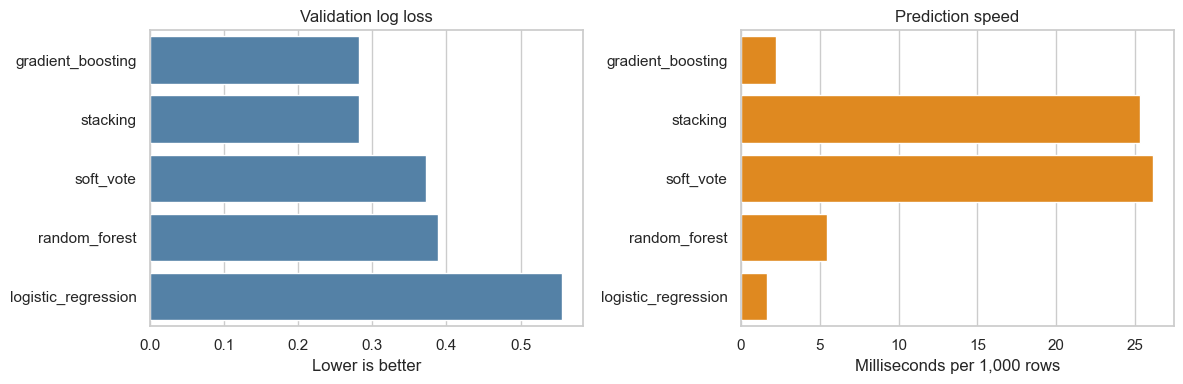

In [24]:
plot_data = all_results.sort_values("log_loss").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_data, x="log_loss", y="model", ax=axes[0], color="steelblue")
axes[0].set_title("Validation log loss")
axes[0].set_xlabel("Lower is better")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_data,
    x="prediction_ms_per_1000_rows",
    y="model",
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Prediction speed")
axes[1].set_xlabel("Milliseconds per 1,000 rows")
axes[1].set_ylabel("")

plt.tight_layout()


### Recommendation checkpoint

A good answer should mention both performance and complexity.

Example structure:

> I recommend `____` because it gives `____` performance while keeping `____` complexity. I would not choose `____` because its improvement is `____` and its operational cost is `____`.

This checkpoint helps students move from coding to model judgment.


## 8. Tune the decision threshold

The default threshold is 0.5, but business problems often need a different threshold.

For example, if missing a likely subscriber is expensive, we may accept more false positives to increase recall. If contacting customers is expensive, we may require higher precision.

This simple table shows how precision and recall change as the threshold changes.


In [25]:
def threshold_report(model, X_valid, y_valid, thresholds):
    probability = model.predict_proba(X_valid)[:, 1]
    rows = []

    for threshold in thresholds:
        prediction = (probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, prediction, labels=[0, 1]).ravel()
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_valid, prediction, zero_division=0),
            "recall": recall_score(y_valid, prediction, zero_division=0),
            "predicted_positive_rate": prediction.mean(),
            "false_positives": fp,
            "false_negatives": fn,
        })

    return pd.DataFrame(rows)

recommended_model_name = best_single_model
recommended_model = fitted_models[recommended_model_name]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]
threshold_report(recommended_model, X_val, y_val, thresholds).round(4)


,threshold,precision,recall,predicted_positive_rate,false_positives,false_negatives
0,0.1,0.2945,0.6952,0.2761,2202,403
1,0.2,0.4665,0.5272,0.1322,797,625
2,0.3,0.5262,0.4402,0.0979,524,740
3,0.4,0.5674,0.3313,0.0683,334,884
4,0.5,0.6393,0.2239,0.0410,167,1026


### Threshold discussion

Threshold choice should come from business costs, not from habit.

Ask students:

- What is worse here: contacting too many uninterested customers or missing interested customers?
- Who should decide that trade-off: the data scientist alone or the business owner?
- Which threshold would you choose if the campaign team has limited call capacity?


## 9. Check probability calibration

Calibration asks whether predicted probabilities behave like real probabilities.

If a model gives many customers a probability near 0.30, then roughly 30% of those customers should subscribe for the model to be well-calibrated.

Calibration matters when probabilities drive business decisions, budgets, or customer prioritization.


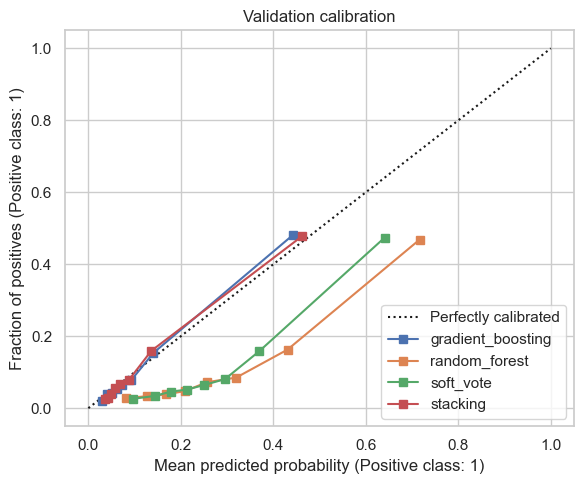

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))

for name in ["gradient_boosting", "random_forest", "soft_vote", "stacking"]:
    probabilities = fitted_models[name].predict_proba(X_val)[:, 1]
    CalibrationDisplay.from_predictions(
        y_val,
        probabilities,
        n_bins=8,
        strategy="quantile",
        name=name,
        ax=ax,
    )

ax.set_title("Validation calibration")
plt.tight_layout()


## Final practical recommendation

Use this decision rule:

1. Start with the best single model.
2. Try soft voting because it is simple and easy to explain.
3. Try stacking only if voting is not enough.
4. Prefer the simplest model when validation performance is close.
5. Tune the threshold based on business costs.

For this problem, a strong gradient boosting model is likely the best default recommendation unless stacking gives a clearly meaningful improvement. It is easier to explain, deploy, monitor, and debug than a stacked ensemble.

## Best-practice checklist

Before deploying an ensemble, confirm that:

- The ensemble beats a strong single-model baseline on validation data.
- The improvement is large enough to matter for the business.
- The extra training and prediction time is acceptable.
- The probability quality is good enough for threshold decisions.
- The team can monitor and maintain every model in the ensemble.
- The final test set has not been used repeatedly for model selection.

## Common mistakes

- Building an ensemble before building strong individual baselines.
- Training a stacker on in-sample predictions from base models.
- Comparing many ensembles on the test set and picking the winner.
- Ignoring probability calibration and prediction latency.
- Keeping a complex ensemble when the improvement is tiny.

## Exercises

1. Remove logistic regression from the voting ensemble. Does validation performance improve or get worse?
2. Change the voting weights to favor gradient boosting. What happens to log loss and recall?
3. Increase the stacking CV folds from 3 to 5. Is the result worth the extra training time?
4. Pick a threshold for a campaign with limited call capacity and justify it.
5. Write a short production recommendation for either gradient boosting or stacking.

## Key takeaway

Ensembles are useful when they create enough measurable value to justify their complexity. In applied machine learning, the best model is not just the one with the best metric. It is the model that performs well, can be trusted, and can be operated reliably.



## Common mistakes and leakage warnings

- Comparing ensemble members without keeping preprocessing inside the pipeline.
- Letting stacking see in-sample predictions from the same rows it will learn from.
- Optimizing on the test set or repeatedly reusing validation after the decision is made.

## Exercises

1. Compare soft voting with stacking under the same cross-validation protocol.
2. Measure latency and calibration trade-offs for each ensemble.
3. **Challenge:** explain when a simpler model should beat an ensemble in production.

## Summary

Ensembles can help when base models are useful and diverse, but added complexity has real operational cost.

## References

- [scikit-learn ensemble methods](https://scikit-learn.org/stable/modules/ensemble.html)
- [StackingClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)
